# 03 - EDA: Graph Structure

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

DATASET_DIR = Path("../dataset")
FIGURES_DIR = Path("../results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

FEATURES_PATH = DATASET_DIR / "elliptic_txs_features.csv"
CLASSES_PATH = DATASET_DIR / "elliptic_txs_classes.csv"
EDGES_PATH = DATASET_DIR / "elliptic_txs_edgelist.csv"

In [2]:
nodes_df = pd.read_csv(
    FEATURES_PATH,
    header=None,
    usecols=[0, 1],
    names=["tx_id", "time_step"],
)

classes_df = pd.read_csv(CLASSES_PATH).rename(
    columns={"txId": "tx_id", "class": "label"}
)

edges_df = pd.read_csv(EDGES_PATH).rename(
    columns={"txId1": "source_tx_id", "txId2": "target_tx_id"}
)

label_mapping = {
    "1": "illicit",
    "2": "licit",
    "unknown": "unknown",
}

nodes_df = nodes_df.merge(
    classes_df,
    on="tx_id",
    how="left",
    validate="one_to_one",
)

nodes_df["label_name"] = nodes_df["label"].astype(str).map(label_mapping)

display(nodes_df.head())
display(edges_df.head())

,tx_id,time_step,label,label_name
0,230425980,1,unknown,unknown
1,5530458,1,unknown,unknown
2,232022460,1,unknown,unknown
3,232438397,1,2,licit
4,230460314,1,unknown,unknown


,source_tx_id,target_tx_id
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


In [3]:
assert nodes_df.shape == (203_769, 4)
assert edges_df.shape == (234_355, 2)
assert nodes_df["tx_id"].is_unique
assert not edges_df.duplicated().any()

print("Nodes:", len(nodes_df))
print("Edges:", len(edges_df))
print("Duplicated edges:", edges_df.duplicated().sum())

Nodes: 203769
Edges: 234355
Duplicated edges: 0


In [4]:
graph = nx.DiGraph()

graph.add_nodes_from(nodes_df["tx_id"])
graph.add_edges_from(
    edges_df[["source_tx_id", "target_tx_id"]].itertuples(
        index=False,
        name=None,
    )
)

print("Graph nodes:", graph.number_of_nodes())
print("Graph edges:", graph.number_of_edges())

Graph nodes: 203769
Graph edges: 234355


In [5]:
degree_df = nodes_df[["tx_id", "time_step", "label_name"]].copy()

degree_df["in_degree"] = degree_df["tx_id"].map(dict(graph.in_degree()))
degree_df["out_degree"] = degree_df["tx_id"].map(dict(graph.out_degree()))
degree_df["total_degree"] = degree_df["in_degree"] + degree_df["out_degree"]

display(degree_df.head())
display(degree_df[["in_degree", "out_degree", "total_degree"]].describe().round(2))

,tx_id,time_step,label_name,in_degree,out_degree,total_degree
0,230425980,1,unknown,1,1,2
1,5530458,1,unknown,1,1,2
2,232022460,1,unknown,1,2,3
3,232438397,1,licit,160,1,161
4,230460314,1,unknown,2,8,10


,in_degree,out_degree,total_degree
count,203769.00,203769.00,203769.00
mean,1.15,1.15,2.30
std,3.91,1.89,4.33
min,0.00,0.00,1.00
25%,0.00,1.00,1.00
50%,1.00,1.00,2.00
75%,1.00,1.00,2.00
max,284.00,472.00,473.00


In [6]:
weak_components = list(nx.weakly_connected_components(graph))
largest_component_size = max(map(len, weak_components))

graph_summary = pd.Series(
    {
        "nodes": graph.number_of_nodes(),
        "edges": graph.number_of_edges(),
        "average_total_degree": degree_df["total_degree"].mean(),
        "median_total_degree": degree_df["total_degree"].median(),
        "max_in_degree": degree_df["in_degree"].max(),
        "max_out_degree": degree_df["out_degree"].max(),
        "isolated_nodes": nx.number_of_isolates(graph),
        "weakly_connected_components": len(weak_components),
        "largest_weak_component": largest_component_size,
        "graph_density": nx.density(graph),
    },
    name="value",
)

display(graph_summary.to_frame())

,value
nodes,203769.000000
edges,234355.000000
average_total_degree,2.300203
median_total_degree,2.000000
max_in_degree,284.000000
max_out_degree,472.000000
isolated_nodes,0.000000
weakly_connected_components,49.000000
largest_weak_component,7880.000000
graph_density,0.000006


In [7]:
assert graph.number_of_nodes() == 203_769
assert graph.number_of_edges() == 234_355
assert nx.number_of_isolates(graph) == 0

assert degree_df["in_degree"].max() == 284
assert degree_df["out_degree"].max() == 472

print("Basic graph checks passed.")

Basic graph checks passed.


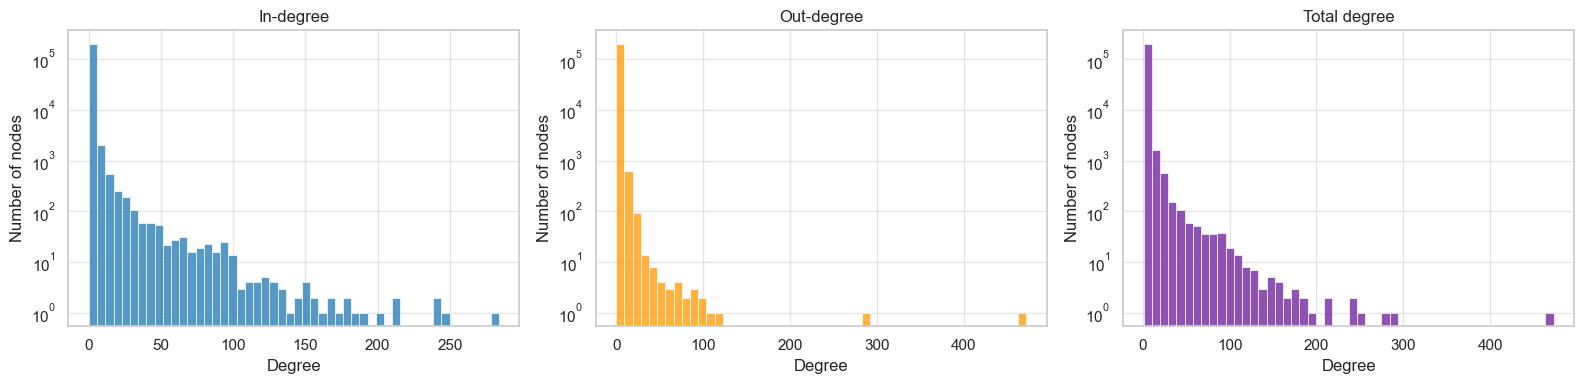

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

columns = ["in_degree", "out_degree", "total_degree"]
titles = ["In-degree", "Out-degree", "Total degree"]
colors = ["#1f77b4", "#ff9800", "#6a1b9a"]

for ax, column, title, color in zip(axes, columns, titles, colors):
    sns.histplot(
        degree_df[column],
        bins=50,
        ax=ax,
        color=color,
    )
    ax.set_title(title)
    ax.set_xlabel("Degree")
    ax.set_ylabel("Number of nodes")
    ax.set_yscale("log")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "degree_histograms.png", dpi=150)
plt.show()

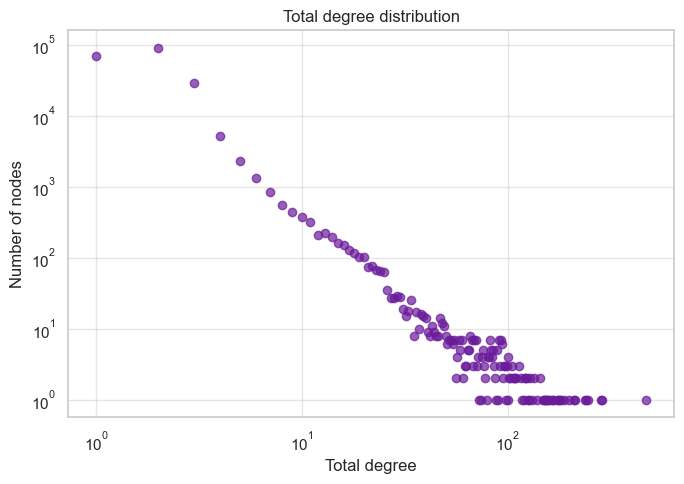

In [9]:
degree_distribution = degree_df["total_degree"].value_counts().sort_index()

degree_distribution = degree_distribution[degree_distribution.index > 0]

plt.figure(figsize=(7, 5))

plt.scatter(
    degree_distribution.index,
    degree_distribution.values,
    alpha=0.7,
    color="#6a1b9a",
)

plt.xscale("log")
plt.yscale("log")
plt.title("Total degree distribution")
plt.xlabel("Total degree")
plt.ylabel("Number of nodes")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "degree_distribution_loglog.png", dpi=150)
plt.show()

In [10]:
degree_by_class = (
    degree_df.groupby("label_name")[["in_degree", "out_degree", "total_degree"]]
    .agg(["count", "mean", "median", "max"])
    .round(2)
)

display(degree_by_class)

in_degree                   out_degree                    \
               count  mean median  max      count  mean median  max   
label_name                                                            
illicit         4545  1.27    1.0  177       4545  0.74    1.0    3   
licit          42019  1.91    1.0  284      42019  1.19    1.0  472   
unknown       157205  0.94    1.0  212     157205  1.15    1.0  122   

           total_degree                    
                  count  mean median  max  
label_name                                 
illicit            4545  2.01    1.0  177  
licit             42019  3.10    2.0  473  
unknown          157205  2.10    2.0  212

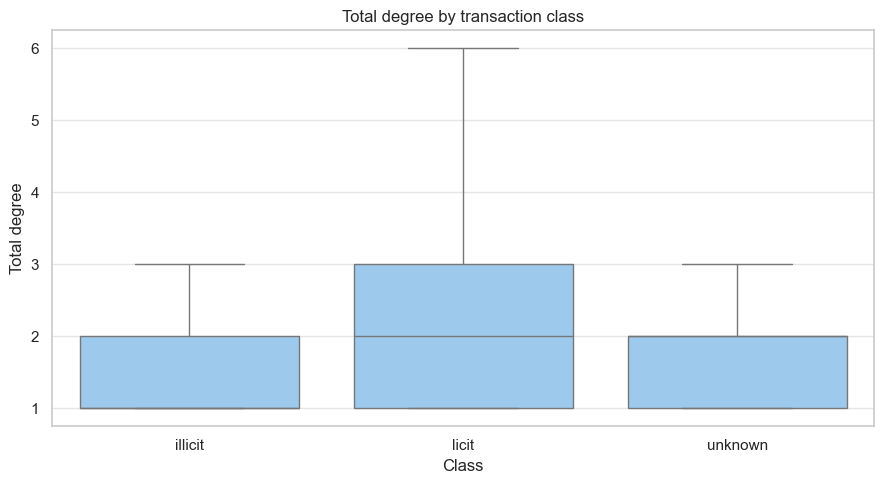

In [11]:
CLASS_ORDER = ["illicit", "licit", "unknown"]

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=degree_df,
    x="label_name",
    y="total_degree",
    order=CLASS_ORDER,
    showfliers=False,
    color="#90caf9",
)

plt.title("Total degree by transaction class")
plt.xlabel("Class")
plt.ylabel("Total degree")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "degree_by_class.png", dpi=150)
plt.show()

In [12]:
node_time_steps = nodes_df.set_index("tx_id")["time_step"]

edges_with_time = edges_df.assign(
    source_time_step=edges_df["source_tx_id"].map(node_time_steps),
    target_time_step=edges_df["target_tx_id"].map(node_time_steps),
)

cross_time_edges = edges_with_time[
    edges_with_time["source_time_step"] != edges_with_time["target_time_step"]
]

print("Edges between different time steps:", len(cross_time_edges))

assert cross_time_edges.empty

Edges between different time steps: 0


In [13]:
nodes_by_time = nodes_df.groupby("time_step").size().rename("nodes")

edges_by_time = edges_with_time.groupby("source_time_step").size().rename("edges")

graph_time_summary = pd.concat(
    [nodes_by_time, edges_by_time],
    axis=1,
).fillna(0)

graph_time_summary["edges"] = graph_time_summary["edges"].astype(int)

graph_time_summary["average_total_degree"] = (
    2 * graph_time_summary["edges"] / graph_time_summary["nodes"]
)

display(graph_time_summary.head())

,nodes,edges,average_total_degree
1,7880,9164,2.325888
2,4544,5241,2.306778
3,6621,8316,2.512007
4,5693,8180,2.873705
5,6803,8623,2.535058


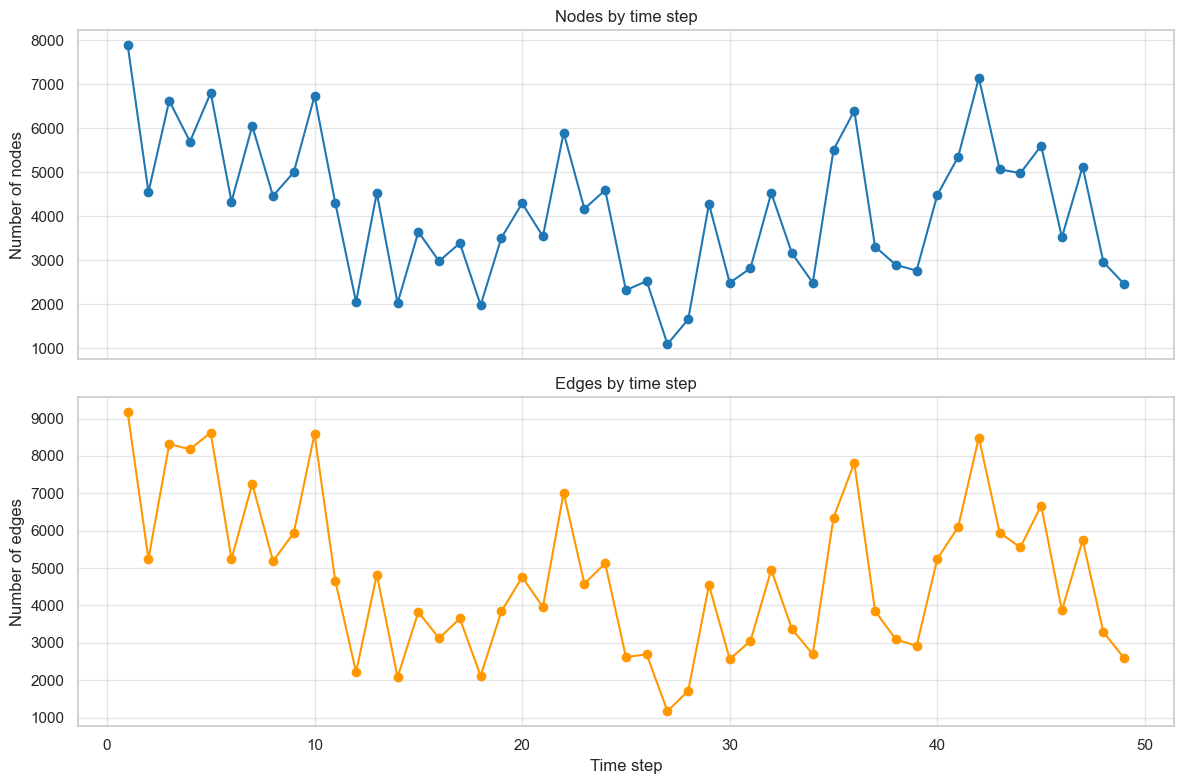

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(
    graph_time_summary.index,
    graph_time_summary["nodes"],
    marker="o",
    color="#1f77b4",
)
axes[0].set_title("Nodes by time step")
axes[0].set_ylabel("Number of nodes")

axes[1].plot(
    graph_time_summary.index,
    graph_time_summary["edges"],
    marker="o",
    color="#ff9800",
)
axes[1].set_title("Edges by time step")
axes[1].set_xlabel("Time step")
axes[1].set_ylabel("Number of edges")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "graph_size_by_time_step.png", dpi=150)
plt.show()

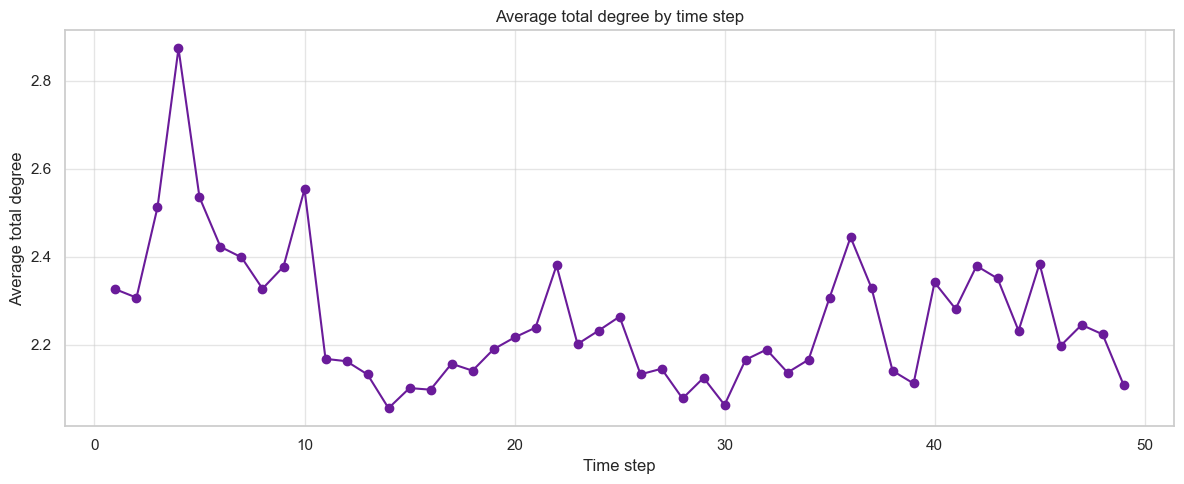

In [15]:
plt.figure(figsize=(12, 5))

plt.plot(
    graph_time_summary.index,
    graph_time_summary["average_total_degree"],
    marker="o",
    color="#6a1b9a",
)

plt.title("Average total degree by time step")
plt.xlabel("Time step")
plt.ylabel("Average total degree")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "average_degree_by_time_step.png", dpi=150)
plt.show()

In [16]:
selected_time_step = 20

illicit_candidates = nodes_df[
    (nodes_df["time_step"] == selected_time_step)
    & (nodes_df["label_name"] == "illicit")
]

selected_tx_id = illicit_candidates.iloc[0]["tx_id"]

neighbors = set(graph.predecessors(selected_tx_id))
neighbors.update(graph.successors(selected_tx_id))

second_level_neighbors = set()

for neighbor in list(neighbors):
    second_level_neighbors.update(graph.predecessors(neighbor))
    second_level_neighbors.update(graph.successors(neighbor))

selected_nodes = {selected_tx_id} | neighbors | second_level_neighbors
selected_nodes.add(selected_tx_id)

subgraph = graph.subgraph(selected_nodes).copy()

print("Selected transaction:", selected_tx_id)
print("Subgraph nodes:", subgraph.number_of_nodes())
print("Subgraph edges:", subgraph.number_of_edges())

Selected transaction: 209952987
Subgraph nodes: 13
Subgraph edges: 12


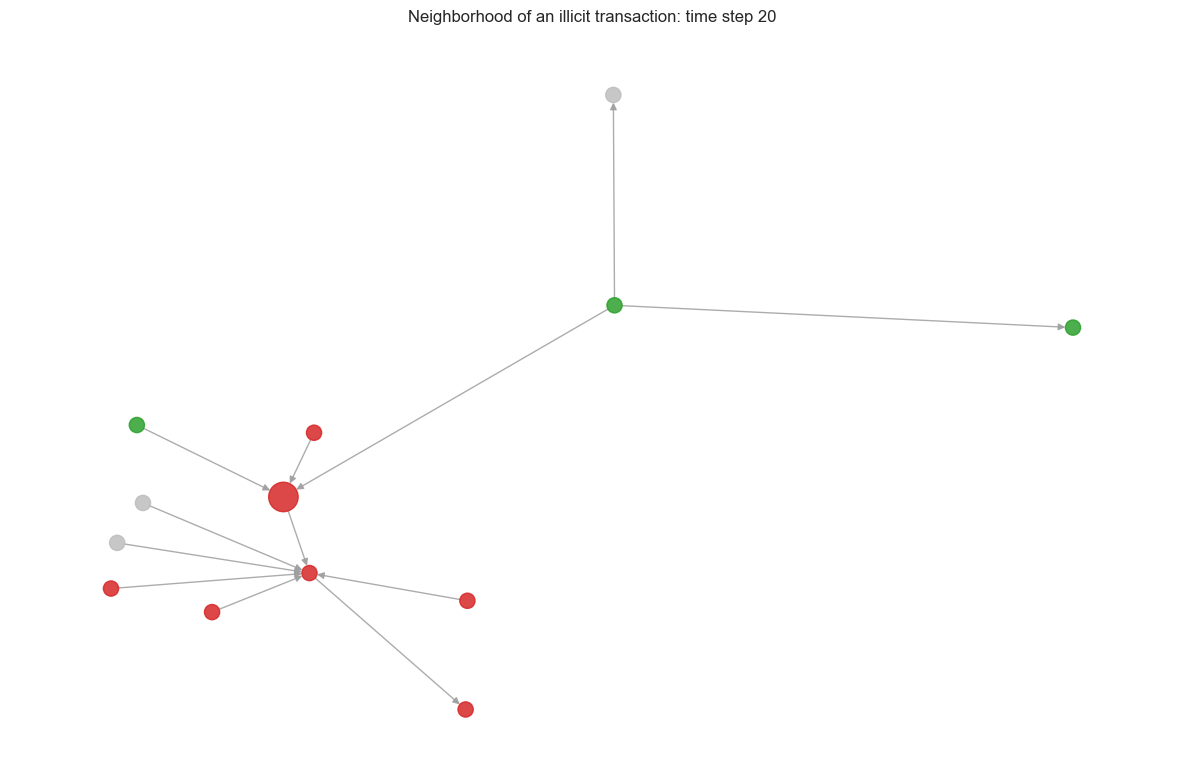

In [17]:
node_labels = nodes_df.set_index("tx_id")["label_name"].to_dict()

NODE_COLORS = {
    "illicit": "#d62728",
    "licit": "#2ca02c",
    "unknown": "#bdbdbd",
}

colors = [NODE_COLORS[node_labels[node]] for node in subgraph.nodes]

sizes = [450 if node == selected_tx_id else 120 for node in subgraph.nodes]

plt.figure(figsize=(12, 8))

positions = nx.spring_layout(
    subgraph,
    seed=42,
)

nx.draw_networkx(
    subgraph,
    pos=positions,
    node_color=colors,
    node_size=sizes,
    arrows=True,
    arrowsize=10,
    with_labels=False,
    edge_color="#9e9e9e",
    alpha=0.85,
)

plt.title(f"Neighborhood of an illicit transaction: time step {selected_time_step}")
plt.axis("off")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "illicit_transaction_subgraph.png", dpi=150)
plt.show()